<a href="https://colab.research.google.com/github/DanialNayyar/Machine-learning-foundations/blob/main/HOML_Chp3_MNIST_Walkthrough_and_Notes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml("mnist_784", as_frame= False) #mnist is images, hence why as_frame = as dataframe is set to false. Will return as a np aray

In [ ]:
X,y = mnist.data, mnist.target

In [ ]:
X # numpy array

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [ ]:
X.shape #70,000 images, each image has 784 features

(70000, 784)

In [ ]:
y#also an array

array(['5', '0', '4', ..., '4', '5', '6'], dtype=object)

In [ ]:
y.shape

(70000,)

In [ ]:
# to plot the image
def plot_digit(image):
  image = image.reshape(28,28) # will reshape it into a 28 x 28 array (sqrt of 784 = 28)
  plt.imshow(image, cmap="binary")
  plt.axis("off")


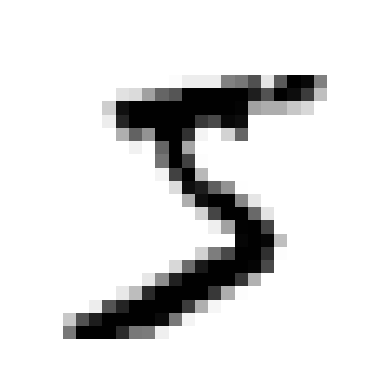

In [ ]:
first_digit_image = X[0]

plot_digit(first_digit_image) # looks like a 5

In [ ]:
y[0]  # is a 5

'5'

In [ ]:
# the mnist dataset (returned by fetch_openml is split into a training (first 60k) and test set (last 10k) already)

X_train, y_train, X_test, y_test = X[:60000], y[:60000], X[60000:], y[60000:] # this one is shuffled and split but not all fetch_openml datasets are

**Binary Classifier**

In [ ]:
y_train_5 = (y_train == "5") # True for all 5s, False for all other digits
y_test_5 = (y_test == "5")

In [ ]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

SGDClassifier(random_state=42)

In [ ]:
sgd_clf.predict([first_digit_image])

array([ True])

In [ ]:
second_digit_image = X[1]
sgd_clf.predict([second_digit_image]) #second_digit_image

array([False])

In [ ]:
y[1]

'0'

In [ ]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

In [ ]:
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier() # strat is most frequent
dummy.fit(X_train, y_train_5)
cross_val_score(dummy, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.90965, 0.90965, 0.90965])

In [ ]:
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)


In [ ]:
y_train_pred # returned prediction

array([ True, False, False, ...,  True, False, False])

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train_5, y_train_pred)

# Cm shows that the model is good at knowing what isnt a 5, but isnt good at knowing what is a 5

array([[53892,   687],
       [ 1891,  3530]])

In [ ]:
from sklearn.metrics import precision_score, recall_score

print(precision_score(y_train_5, y_train_pred)*100)
print(recall_score(y_train_5, y_train_pred)*100)

83.70879772350011
65.11713705958311


In [ ]:
from sklearn.metrics import f1_score

print(f1_score(y_train_5, y_train_pred))

0.7325171197343847


# Notes

-  Binary Classifier - distinguishes between two classes (e.g. 5 or not 5)
- Classifiers cannot be measured with normal cross-validation, the results from CV are misleading.It only answers what percentage of predictions were correct. It hides the mistakes the model makes and it treats all mistakes as equally bad (false negatives may be more serious then a false positive).

e.g. Medical Dataset
- No disease: 950
- Disease: 50

Accuracy - 95% but is useless in finding the important class.

Instead of accuracy, mertrics like:
- Recall: out of actual cancer cases how many were predicted correctly i.e. how many were caught
- Precision: Out of all predicted cancer cases, how many were actually cancer?
- F1-Score: Balance between Precision and Recall

### Confusion Matricies

Count the number of timesinstances of class A are classified as class B for all A/B pairs. Use cross_val_predict() function to get the predictions on out of sample training sets. i.e. makes a prediction on test fold.

With cross_val_predict() there is no averaging of the output like there is with the cross_val_score() function. with CVP. the predictions look like this:
```
Dataset rows:  0  1  2  3  4  5  6  7  8

Fold 1 test:   0  1  2
Fold 2 test:            3  4  5
Fold 3 test:                     6  7  8

```

The the predictions are stiched together at the end in the order of the dataset row i.e. original row.


#### How to read a Confusion Matrix:

```

array([[53892,   687],
       [ 1891,  3530]])

                   PREDICTED NEGATIVE        PREDICTIED POSITIVE
ACTUAL NEGATIVE      True Negative             False Positive
ACTUAL PRODUCTIVE    False Negative            Total Positive


Therefore:
- True Negative: 53892, The model correctly identified 53892 non-5 digits as not being 5
- False Positives: 687, The model incorrectly said 687 non-5s were 5s
- False Negatives: 1891, The model did not catch 1891 5s as 5s
- True Positives: 3530, Correctly identified 3530 5s as actually being 5s

```
### Precision and Recall

There are other metrics aside from the confusion matrix that are very usefull to use:

- Precision:

```
Precision = True Positive / (True Positive + False Positive)

"When the model predicts a 5, how often is the model actually correct"

Given that True Positive = 3530 and False Positive equal 687
Precision = 3530/(3530+687) = 83.7%


i.e. out of all the predictions of a 5, the model was correct 83.7% of the time, i.e. 83.7% of them were a 5.
```


- Recall:

```
Recall = True Positive / (True Positive + False Negative)

"Out of all the actual 5s, how many did the model successfully find"

Given that True Positive = 3530, and False Negative = 1891
Recall = 3530/(3530+1891) = 65.1%

i.e. out of all the real 5s in the dataset, the model found 65% of them

```

- F1 Score:
Combination of precision and recall to give a single metric. Useful when needing to compare to classifiers.
The F1 score is the harmonic mean of precision and recall. The harmonic mean gives more weight to low values as a result, the model will only get a high F1 score if the both recall and precision are high.

It asks "how well is the balance between both precision and recall"

```
F1 = (2*precision*recall)/(precision+recall)
```

The use of the harmonic mean instead of normal mean is to prevent one very good metric hiding the score of the other very bad metric. It favours, classifers that have a similar precisiona and recall score. This isnt always good and not always required. In some cases, e.g. detecting if a video is child friendly or not. A low recall (rejecting many safe videos) but a high precision score (keeping safe videos) may be prefered.


Unfortunately, cant have both high precision and high recall. There is a precision/recall trade off.


## Precision/Recall Trade-off
------------------------------------------------------------------


# Ideas